In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/build-in-model-weights/last_epoch_build_in_saved_weights.pt
/kaggle/input/build-in-model-weights/saved_build_in_weights.pt
/kaggle/input/build-in-model-weights/learn_build_in_rated.pt
/kaggle/input/build-in-model-weights/best_bleu_build_in_model.pt
/kaggle/input/englishvietnamese-translation/vi_sents
/kaggle/input/englishvietnamese-translation/en_sents
/kaggle/input/model-weights/last_epoch_saved_weights.pt
/kaggle/input/model-weights/best_bleu_model.pt
/kaggle/input/model-weights/saved_weights.pt
/kaggle/input/model-weights/learn_rated.pt


In [2]:
pip install underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 52.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install torch==2.3.0 torchtext==0.18.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import torch
import torch.nn as nn
from torch import Tensor
from torch.nn import Transformer
from underthesea import word_tokenize
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from typing import Iterable, List
#from gensim.models import KeyedVectors
from torch.nn.utils.rnn import pad_sequence
import math
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import torch.nn.functional as F
import re
import string

/usr/local/lib/python3.12/dist-packages/torchtext/data/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated

In [5]:
data_dir = "/kaggle/input/englishvietnamese-translation/"
src_dir = data_dir + "en_sents"
tgt_dir = data_dir + "vi_sents"

In [6]:
#Show example of data
org_text = open(src_dir, 'r').read().splitlines()
target_text = open(tgt_dir, 'r').read().splitlines()
data = pd.DataFrame({'en': org_text, 'vi': target_text})
print(len(org_text))
data.head(10)

254090


,en,vi
0,Please put the dustpan in the broom closet,xin vui lòng đặt người quét rác trong tủ chổi
1,Be quiet for a moment.,im lặng một lát
2,Read this,đọc này
3,Tom persuaded the store manager to give him ba...,tom thuyết phục người quản lý cửa hàng trả lại...
4,Friendship consists of mutual understanding,tình bạn bao gồm sự hiểu biết lẫn nhau
5,Are you going to come tomorrow?,ngày mai bạn có đến không
6,"See to this matter right away, will you?","nhìn thấy vấn đề này ngay lập tức, bạn sẽ?"
7,I showed my friends these picture postcards.,tôi đã cho bạn bè của tôi xem những tấm bưu th...
8,Mary is the youngest of the three sisters,mary là em út trong ba chị em
9,He has two aunts on his mother's side.,anh ấy có hai người dì ở bên mẹ.


In [7]:
import string
#Create Vocabulary
#Lowercase all sentence
data['en'] = data['en'].apply(lambda x: x.lower())
data['vi'] = data['vi'].apply(lambda x: x.lower())
#Remove punctuation
data['en'] = data['en'].apply(lambda x : x.translate(str.maketrans('', '', string.punctuation)))
data['vi'] = data['vi'].apply(lambda x : x.translate(str.maketrans('', '', string.punctuation)))
#Remove blank space from beginning and end of sentence
data['en'] = data['en'].apply(lambda x : x.strip())
data['vi'] = data['vi'].apply(lambda x : x.strip())
#Remove special index
data['en'] = data['en'].str.replace(r"\s+", " ", regex=True)
data['vi'] = data['vi'].str.replace(r"\s+", " ", regex=True)
data.head(10)

,en,vi
0,please put the dustpan in the broom closet,xin vui lòng đặt người quét rác trong tủ chổi
1,be quiet for a moment,im lặng một lát
2,read this,đọc này
3,tom persuaded the store manager to give him ba...,tom thuyết phục người quản lý cửa hàng trả lại...
4,friendship consists of mutual understanding,tình bạn bao gồm sự hiểu biết lẫn nhau
5,are you going to come tomorrow,ngày mai bạn có đến không
6,see to this matter right away will you,nhìn thấy vấn đề này ngay lập tức bạn sẽ
7,i showed my friends these picture postcards,tôi đã cho bạn bè của tôi xem những tấm bưu th...
8,mary is the youngest of the three sisters,mary là em út trong ba chị em
9,he has two aunts on his mothers side,anh ấy có hai người dì ở bên mẹ


In [8]:
#Tokenize for both language
token_transform = {}
vocab_transform = {}
def vi_tokenize(sentence):
  token = word_tokenize(sentence)
  return token
src_lang = 'en'
tgt_lang = 'vi'
token_transform[tgt_lang] = get_tokenizer(vi_tokenize)
token_transform[src_lang] = get_tokenizer('basic_english')

def yield_token(data_iter: Iterable, language: str) -> List[str]:
    for idx, data_row in data_iter:
      yield token_transform[language](data_row[language])

#Define special symbols and indicies
UNK, PAD, BOS, EOS = 0, 1, 2, 3
special_sym = ['<unk>','<pad>','<bos>','<eos>']

for lang in [src_lang, tgt_lang]:
  train_iter = data.iterrows()
  #Create Vocabulary
  vocab_transform[lang] = build_vocab_from_iterator(yield_token(train_iter,lang),
                                                    min_freq=1, specials = special_sym)
#Set UNK as default
for lang in [src_lang, tgt_lang]:
  vocab_transform[lang].set_default_index(UNK)

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class PositionalEncoding(nn.Module):
    def __init__(self, emb_size: int, dropout: float, max_len: int = 5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, 1, emb_size)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, emb_size, 2).float() * (-math.log(10000.0) / emb_size))

        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)
class TokenEmbedding(nn.Module):
  def __init__(self, vocab_size, emb_size):
    super(TokenEmbedding, self).__init__()
    self.embedding = nn.Embedding(vocab_size,emb_size)
    self.emb_size = emb_size
  def forward(self, tokens: Tensor):
    return self.embedding(tokens.long()) * math.sqrt(self.emb_size) #scaling down
#Combine pos encode and token embedding togerther
class TransformerEmbedding(nn.Module):
  def __init__(self, vocab_size, emb_size, max_len, dropout):
    super(TransformerEmbedding, self).__init__()
    self.tok_emb = TokenEmbedding(vocab_size,emb_size)
    self.pos_emb = PositionalEncoding(emb_size,dropout,max_len)
    self.dropout = nn.Dropout(dropout)
  def forward(self, x):
    return self.dropout(self.pos_emb(self.tok_emb(x)))

In [10]:
class MultiHeadAttention(nn.Module):
    def __init__(self, emb_size, n_head):
        super(MultiHeadAttention, self).__init__()
        self.emb_size = emb_size
        self.n_head = n_head
        self.d_k = emb_size // n_head

        self.w_q = nn.Linear(emb_size, emb_size)
        self.w_k = nn.Linear(emb_size, emb_size)
        self.w_v = nn.Linear(emb_size, emb_size)
        self.w_o = nn.Linear(emb_size, emb_size)
        self.softmax = nn.Softmax(dim=-1)

    def split_heads(self, x):
        seq_len, batch_size, _ = x.size()
        return x.view(seq_len, batch_size, self.n_head, self.d_k).permute(1, 2, 0, 3)

    def combine_head(self, x):
        batch_size, _, seq_len, _ = x.size()
        return x.permute(2, 0, 1, 3).contiguous().view(seq_len, batch_size, self.emb_size)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        K_T = K.transpose(-2, -1) 

        scores = torch.matmul(Q, K_T) / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attn = self.softmax(scores)
        self.attn_weights = attn.detach().cpu()
        
        return torch.matmul(attn, V)

    def forward(self, q, k, v, mask=None):
        Q = self.split_heads(self.w_q(q))
        K = self.split_heads(self.w_k(k))
        V = self.split_heads(self.w_v(v))

        attn_out = self.scaled_dot_product_attention(Q, K, V, mask)
        
        return self.w_o(self.combine_head(attn_out))

In [11]:
class PostionWiseFeedForward(nn.Module):
  def __init__(self, d_model, d_ff, dropout=0.1):
    super(PostionWiseFeedForward, self).__init__()
    self.fc1 = nn.Linear(d_model, d_ff)
    self.fc2 = nn.Linear(d_ff, d_model)
    self.relu = nn.ReLU()  
    self.dropout = nn.Dropout(dropout)
  def forward(self, x):
    x = self.fc1(x)
    x = self.relu(x)
    x = self.dropout(x)
    x = self.fc2(x)
    return x

In [12]:
class EncoderLayer(nn.Module):
  def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
    super(EncoderLayer, self).__init__()
    self.self_attn = MultiHeadAttention(d_model, n_heads)
    self.norm1 = nn.LayerNorm(d_model)
    self.norm2 = nn.LayerNorm(d_model)
    self.feed_forward = PostionWiseFeedForward(d_model, d_ff, dropout=dropout)
    self.dropout1 = nn.Dropout(dropout)
    self.dropout2 = nn.Dropout(dropout)
  def forward(self, x, mask):
    x2 = self.norm1(x)
    x = x + self.dropout1(self.self_attn(x2, x2, x2, mask))
    x2 = self.norm2(x)
    x = x + self.dropout2(self.feed_forward(x2))
    return x
class DecoderLayer(nn.Module):
  def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
    super(DecoderLayer, self).__init__()
    self.attn1 = MultiHeadAttention(d_model, n_heads)
    self.attn2 = MultiHeadAttention(d_model, n_heads)
    self.norm1 = nn.LayerNorm(d_model)
    self.norm2 = nn.LayerNorm(d_model)
    self.norm3 = nn.LayerNorm(d_model)
    self.feed_forward = PostionWiseFeedForward(d_model, d_ff, dropout=dropout)
    self.dropout1 = nn.Dropout(dropout)
    self.dropout2 = nn.Dropout(dropout)
    self.dropout3 = nn.Dropout(dropout)
  def forward(self, x, memory, src_mask, tgt_mask):
    x2 = self.norm1(x)
    x = x + self.dropout1(self.attn1(x2, x2, x2, tgt_mask))
    x2 = self.norm2(x)
    x = x + self.dropout2(self.attn2(x2, memory, memory, src_mask))
    x2 = self.norm3(x)
    x = x + self.dropout3(self.feed_forward(x2))
    return x

In [13]:
class Encoder(nn.Module):
  def __init__(self, vocab_size, d_model, n_heads, n_layers, max_len, d_ff, dropout=0.1):
    super(Encoder, self).__init__()
    self.n_layers = n_layers
    self.embed = TransformerEmbedding(vocab_size, d_model, max_len, dropout=dropout)
    self.layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout=dropout) for _ in range(n_layers)])
    self.norm = nn.LayerNorm(d_model)
  def forward(self, x, mask):
    x = self.embed(x)
    for i in range(self.n_layers):
      x = self.layers[i](x, mask)
    return self.norm(x)
class Decoder(nn.Module):
  def __init__(self, vocab_size, d_model, n_heads, n_layers, max_len, d_ff, dropout=0.1):
    super(Decoder, self).__init__()
    self.n_layers = n_layers
    self.embed = TransformerEmbedding(vocab_size, d_model, max_len, dropout=dropout)
    self.layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout=dropout) for _ in range(n_layers)])
    self.norm = nn.LayerNorm(d_model)  
  def forward(self, x, memory, src_mask, tgt_mask):
    x = self.embed(x)
    for i in range(self.n_layers):
      x = self.layers[i](x, memory, src_mask, tgt_mask)
    return self.norm(x)

In [14]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, n_heads, d_ff, n_layers, max_len, dropout):
        super(Transformer, self).__init__()
        
        self.encoder = Encoder(src_vocab_size, d_model, n_heads, n_layers, max_len, d_ff, dropout=dropout)
        self.decoder = Decoder(tgt_vocab_size, d_model, n_heads, n_layers, max_len, d_ff, dropout=dropout)
        self.linear = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)

    def generate_mask(self, src, tgt):

        src_seq_len = src.size(0)
        tgt_seq_len = tgt.size(0)

        tgt_mask = torch.triu(torch.ones(tgt_seq_len, tgt_seq_len, device=device), diagonal=1).float()
        tgt_mask = tgt_mask.masked_fill(tgt_mask == 1, float('-inf'))

        tgt_attention_mask = torch.tril(torch.ones(tgt_seq_len, tgt_seq_len, device=device)) == 1
        tgt_attention_mask = tgt_attention_mask.unsqueeze(0).unsqueeze(0) # [1, 1, T, T]

        src_padding_mask = (src != PAD).transpose(0, 1).unsqueeze(1).unsqueeze(2) # [B, 1, 1, S]
        tgt_padding_mask = (tgt != PAD).transpose(0, 1).unsqueeze(1).unsqueeze(2) # [B, 1, 1, T]

        tgt_final_mask = tgt_attention_mask & tgt_padding_mask

        return src_padding_mask, tgt_final_mask

    def forward(self, src, tgt):
        src_mask, tgt_mask = self.generate_mask(src, tgt)
        memory = self.encoder(src, src_mask)
        hidden = self.decoder(tgt, memory, src_mask, tgt_mask)
        output = self.linear(hidden)
        return output
        

In [15]:
def warm_up_scheduler(step_num, emb_size, warm_up_step):
    if step_num == 0: step_num = 1
        
    arg1 = step_num ** -0.5
    arg2 = step_num * (warm_up_step ** -1.5)
    
    return (emb_size ** -0.5) * min(arg1, arg2)

In [16]:
torch.manual_seed(0)
src_vocab_size = len(vocab_transform[src_lang])
tgt_vocab_size = len(vocab_transform[tgt_lang])
EMB_SIZE = 512
N_HEAD = 8
D_FF = 2048
BATCH_SIZE = 64
N_LAYER = 6
DROPOUT = 0.1
MAX_LEN = 256
WARM_UP_STEP = 4000

In [17]:
transformer = Transformer(src_vocab_size, tgt_vocab_size, EMB_SIZE,N_HEAD , D_FF, N_LAYER, MAX_LEN, DROPOUT)
for p in transformer.parameters():
    if p.dim() > 1:
        nn.init.xavier_uniform_(p)

transformer = transformer.to(device)
loss_fn = torch.nn.CrossEntropyLoss(ignore_index=PAD, label_smoothing=0.1)

optimizer = torch.optim.AdamW(transformer.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9, weight_decay=0.01)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',factor=0.5, patience=3, verbose=True)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda = lambda step: warm_up_scheduler(step, EMB_SIZE, WARM_UP_STEP))

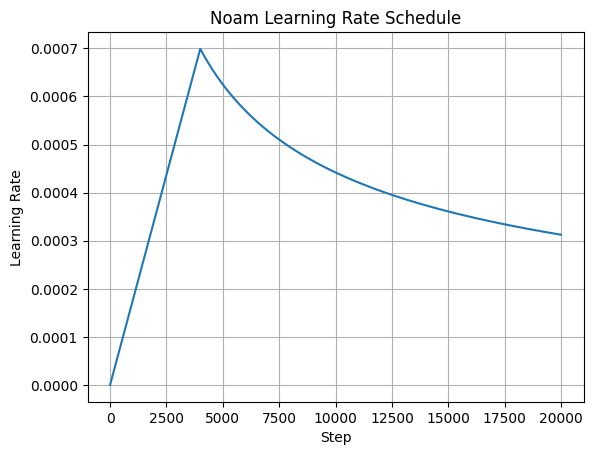

In [18]:
import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(1, 20000)
lrs = [warm_up_scheduler(step, emb_size=512, warm_up_step=4000) for step in steps]

plt.plot(steps, lrs)
plt.title("Noam Learning Rate Schedule")
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.grid(True)
plt.show()

In [19]:
#Data processing
def sequential_transforms(*transforms):
    def func(txt_input):
        for transform in transforms:
            txt_input = transform(txt_input)
        return txt_input
    return func

def tensor_transform(token_ids: List[int]):
    return torch.cat((torch.tensor([BOS]),
                      torch.tensor(token_ids),
                      torch.tensor([EOS])))


text_transform = {}
for ln in [src_lang, tgt_lang]:
    text_transform[ln] = sequential_transforms(token_transform[ln],
                                               vocab_transform[ln], 
                                               tensor_transform) 


def collate_fn(batch):
    src_batch, tgt_batch = [], []

    for src_sample, tgt_sample in batch:
        src_batch.append(text_transform[src_lang](src_sample.rstrip("\n")))
        tgt_batch.append(text_transform[tgt_lang](tgt_sample.rstrip("\n")))

    src_batch = pad_sequence(src_batch, padding_value=PAD)
    tgt_batch = pad_sequence(tgt_batch, padding_value=PAD)
    return src_batch, tgt_batch

In [20]:
#Chia tập train valid test
split_ratio = 0.9
split = round(data.shape[0]* split_ratio)
train = data.iloc[:split]
train_ds = list(zip(train['en'],train['vi']))
valid = data.iloc[split:]
val_ds = list(zip(valid['en'],valid['vi']))

In [21]:
import random
from torch.utils.data import Sampler

class My_Batch_Smapler(Sampler):
  def __init__(self, data_source, batch_size): 
    self.data_source = data_source
    self.batch_size = batch_size 
  def __iter__(self):
    idxs = [(i, len(s[0].split())) for i, s in enumerate(self.data_source)]

   
    sorted_idxs = sorted(idxs, key = lambda x: x[1])

    batches = [sorted_idxs[i: i + self.batch_size] for i in range(0, len(sorted_idxs), self.batch_size)]

    random.shuffle(batches)
    for batch in batches:
      batch_idxs = [idx for idx, _ in batch]
      yield batch_idxs
  def __len__(self):
    return math.ceil(len(self.data_source) / self.batch_size)

In [22]:
from torch.utils.data import DataLoader
from tqdm import tqdm
from torch.cuda.amp import GradScaler, autocast

scaler = GradScaler()
batch_sampler = My_Batch_Smapler(train_ds, BATCH_SIZE)
def train_epoch(model, optimizer, scheduler,build_in = False):
    model.train()
    losses = 0
    train_dataloader = DataLoader(train_ds, batch_sampler = batch_sampler, collate_fn=collate_fn)
    train_iter = tqdm(train_dataloader, desc="Training", position=0,leave=True)
    for src, tgt in train_iter:
        src = src.to(device)
        tgt = tgt.to(device)
        tgt_input = tgt[:-1, :]
        tgt_out = tgt[1:, :]

        optimizer.zero_grad()

        with autocast():
            if build_in:
                src_mask, tgt_mask, src_pad_mask, tgt_pad_mask= generate_mask(src,tgt_input)
                logits = model(src,tgt_input,src_mask,tgt_mask,src_pad_mask,tgt_pad_mask,src_pad_mask)
            else:
                logits = model(src, tgt_input)
            loss = loss_fn(logits.reshape(-1, logits.shape[-1]), tgt_out.reshape(-1))

        # Scale loss và backward để tránh underflow
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        scheduler.step()

        losses += loss.item()
        
        current_lr = optimizer.param_groups[0]['lr']
        train_iter.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{current_lr:.6f}'})
    
    return losses / len(train_dataloader)

def evaluate(model, build_in=False):
    model.eval()
    losses = 0

    val_dataloader = DataLoader(val_ds, batch_size=BATCH_SIZE, collate_fn=collate_fn)
    with torch.no_grad():
        for src, tgt in val_dataloader:
            src = src.to(device)
            tgt = tgt.to(device)
    
            tgt_input = tgt[:-1, :]
            tgt_out = tgt[1:, :]
            if build_in:
                src_mask, tgt_mask, src_pad_mask, tgt_pad_mask= generate_mask(src,tgt_input)
                logits = model(src, tgt_input, src_mask, tgt_mask, src_pad_mask, tgt_pad_mask, src_pad_mask)
            else:
                logits = model(src, tgt_input)
            
            loss = loss_fn(logits.reshape(-1, logits.shape[-1]), tgt_out.reshape(-1))
            losses += loss.item()

    return losses / len(val_dataloader)

In [23]:
def GreedyDecode(model, src, src_mask, max_len, build_in=False):
    src = src.to(device)
    src_mask = src_mask.to(device)

    # 1. Encoder
    memory = model.encoder(src, src_mask)

    # 2. Decoder Loop
    ys = torch.ones(1, 1).fill_(BOS).type(torch.long).to(device)

    for i in range(max_len-1):
        memory = memory.to(device)
        
        sz = ys.shape[0]
        if build_in:
            tgt_mask = generate_square_subsequent_mask(sz).to(device)
        else:
            tgt_mask = (torch.triu(torch.ones(sz, sz, device=device)) == 1).transpose(0, 1)
        
        with torch.no_grad():
            out = model.decoder(ys, memory, src_mask, tgt_mask)
            prob = model.linear(out[-1, :]) # Lấy token cuối cùng
            _, next_word = torch.max(prob, dim=1)
            next_word = next_word.item()

        if next_word == EOS:
            break
            
        ys = torch.cat([ys, torch.ones(1, 1).type_as(src.data).fill_(next_word)], dim=0)

    return ys.transpose(0, 1)
def translate_sentence(model, sentence, build_in=False):
    sentence = sentence.lower()
    sentence = sentence.translate(str.maketrans('', '', string.punctuation))
    sentence = sentence.strip()
    sentence = re.sub(r"\s+", " ", sentence)
    model.eval()
    with torch.no_grad():
        src = text_transform[src_lang](sentence).view(-1, 1).to(device)
        num_tokens = src.shape[0]
        
        src_mask = (src != PAD).transpose(0, 1).unsqueeze(1).unsqueeze(2).to(device)
        
        tgt_tokens = GreedyDecode(model, src, src_mask, max_len=num_tokens + 5,build_in=build_in).flatten()
        
        result = " ".join(vocab_transform[tgt_lang].lookup_tokens(list(tgt_tokens.cpu().numpy())))
        return result.replace("<bos>", "").replace("<eos>", "").strip()

In [24]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
def bleu(model, data, build_in=False):
    pred_tgts = []
    tgts = []
    smth_func = SmoothingFunction()
    model.eval()
    for i, item in enumerate(data):
        src = item[0]
        tgt = item[1]
        #pred_tgt = translate_beam(model,src,beam_k)
        pred_tgt = translate_sentence(model, src, build_in=build_in)

        pred_token = vi_tokenize(pred_tgt)
        tgt_token = vi_tokenize(tgt)

        pred_tgts.append(pred_token)
        tgts.append([tgt_token])
    return corpus_bleu(tgts, pred_tgts, smoothing_function = smth_func.method2)

In [25]:
def bleu_beam(model, data, beam_k = 5,build_in=False):
    pred_tgts = []
    tgts = []
    smth_func = SmoothingFunction()
    model.eval()
    for i, item in enumerate(data):
        src = item[0]
        tgt = item[1]
        pred_tgt = translate_beam(model,src,beam_k,build_in=build_in)
        #pred_tgt = translate_sentence(model, src)

        pred_token = vi_tokenize(pred_tgt)
        tgt_token = vi_tokenize(tgt)

        pred_tgts.append(pred_token)
        tgts.append([tgt_token])
    return corpus_bleu(tgts, pred_tgts, smoothing_function = smth_func.method2)

In [26]:
import time
def train_model(model,history: dict,build_in=False):
    best_valid_loss = float('inf')
    NUM_EPOCHS = 30
    best_bleu = -1.0
    tolerence = 0
    patience = 10
    for epoch in range(1, NUM_EPOCHS+1):
        start_time = time.time()
        train_loss = train_epoch(model, optimizer, scheduler,build_in)
        val_loss = evaluate(model,build_in)
        bleu_score = bleu(model, val_ds[:200],build_in=build_in)
        end_time = time.time()
        #scheduler.step(val_loss)
        history['loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['bleu'].append(bleu_score)
        if bleu_score > best_bleu:
            best_bleu = bleu_score
            if build_in:
                torch.save(model.state_dict(), 'best_bleu_build_in_model.pt')
            else:
                torch.save(model.state_dict(), 'best_bleu_model.pt')
        if val_loss < best_valid_loss:
            tolerence = 0
            best_valid_loss = val_loss
            if build_in:
                torch.save(model.state_dict(), 'saved_build_in_weights.pt')
            else:
                torch.save(model.state_dict(), 'saved_weights.pt')
        else:
            tolerence +=1
        cur_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch: {epoch}, Epoch time = {(end_time - start_time):.3f}s, LR: {cur_lr:.6f}")
        print((f"\tTrain loss: {train_loss:.3f}, Val loss: {val_loss:.3f}, Bleu: {bleu_score*100:.2f}"))
        if tolerence >= patience:
            print(f"Early Stopping at epoch {epoch+1}")
            break
        if epoch == NUM_EPOCHS or epoch % 5 == 0:
            if build_in:
                torch.save(model.state_dict(), 'last_epoch_build_in_saved_weights.pt')
                torch.save(optimizer.state_dict(), 'learn_build_in_rated.pt')
            else:
                torch.save(model.state_dict(), 'last_epoch_saved_weights.pt')
                torch.save(optimizer.state_dict(), 'learn_rated.pt')

In [27]:
scratch_history = {"loss": [],
                   "val_loss": [],
                   "bleu": []}
train_model(transformer,scratch_history)

Training: 100%|██████████| 3574/3574 [07:05<00:00,  8.40it/s, loss=2.7360, lr=0.000624]


Epoch: 1, Epoch time = 465.805s, LR: 0.000624
	Train loss: 3.964, Val loss: 2.686, Bleu: 44.47


Training: 100%|██████████| 3574/3574 [07:02<00:00,  8.46it/s, loss=2.3124, lr=0.000523]


Epoch: 2, Epoch time = 463.138s, LR: 0.000523
	Train loss: 2.509, Val loss: 2.409, Bleu: 50.62


Training: 100%|██████████| 3574/3574 [07:04<00:00,  8.42it/s, loss=2.8678, lr=0.000427]


...

Epoch: 28, Epoch time = 419.045s, LR: 0.000140
	Train loss: 1.586, Val loss: 1.907, Bleu: 73.67


Training: 100%|██████████| 3574/3574 [06:22<00:00,  9.34it/s, loss=1.5821, lr=0.000137]


Epoch: 29, Epoch time = 421.161s, LR: 0.000137
	Train loss: 1.581, Val loss: 1.907, Bleu: 71.14


Training: 100%|██████████| 3574/3574 [06:24<00:00,  9.29it/s, loss=1.6257, lr=0.000135]


Epoch: 30, Epoch time = 423.220s, LR: 0.000135
	Train loss: 1.574, Val loss: 1.907, Bleu: 74.07


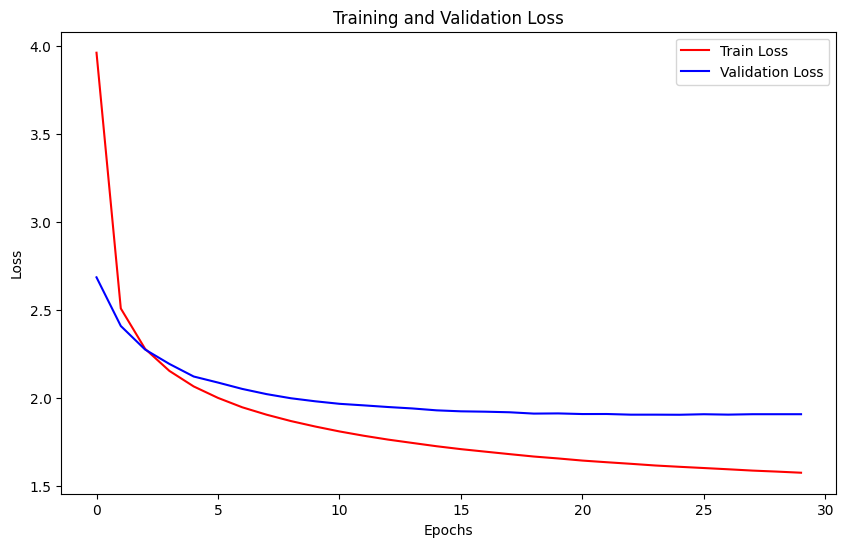

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(scratch_history['loss'], label='Train Loss', color='red')

plt.plot(scratch_history['val_loss'], label='Validation Loss', color='blue') 

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

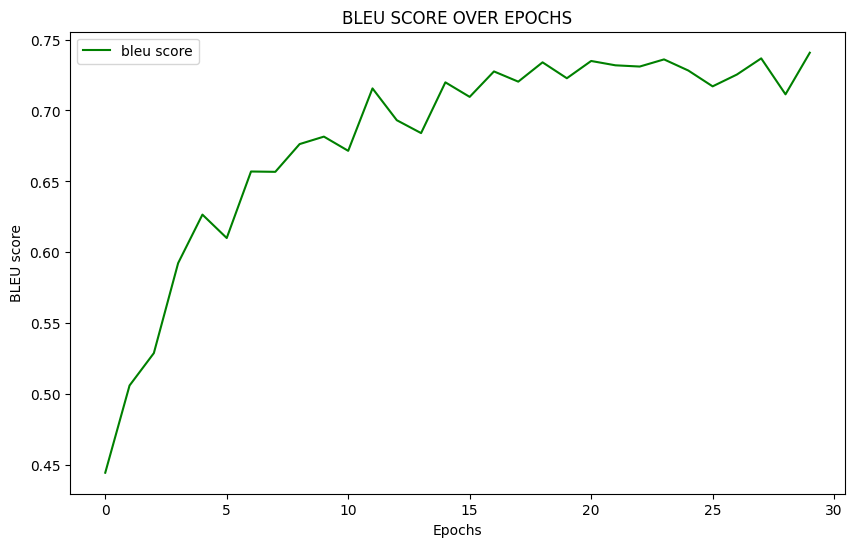

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(scratch_history['bleu'], label='bleu score', color='green')

plt.xlabel('Epochs')
plt.ylabel('BLEU score')
plt.title('BLEU SCORE OVER EPOCHS')
plt.legend()
plt.show()

# Thử lại với bulid in Transformer của pytorch

In [30]:
import torch
import torch.nn as nn

class Build_In_Transformer(nn.Module): 
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, n_heads, d_ff, n_layers, max_len, dropout):
        super(Build_In_Transformer, self).__init__()
        
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=n_heads,
            num_encoder_layers=n_layers,
            num_decoder_layers=n_layers,
            dim_feedforward=d_ff,
            dropout=dropout
        )
        self.linear = nn.Linear(d_model, tgt_vocab_size)
        self.src_embed = TransformerEmbedding(src_vocab_size, d_model, max_len, dropout=dropout)
        self.tgt_embed = TransformerEmbedding(tgt_vocab_size, d_model, max_len, dropout=dropout)
        
    def forward(self, src, tgt, src_mask, tgt_mask, src_padding_mask, tgt_padding_mask, memory_key_padding_mask):
        src_emb = self.src_embed(src)
        tgt_emb = self.tgt_embed(tgt)

        outs = self.transformer(
            src=src_emb, 
            tgt=tgt_emb,
            src_mask=src_mask,
            tgt_mask=tgt_mask,
            memory_mask=None,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask
        )
        return self.linear(outs)

    def encoder(self, src, src_mask, src_key_padding_mask=None):
        if src_key_padding_mask is None:
            # --- FIX QUAN TRỌNG TẠI ĐÂY ---
            # Phải so sánh với PAD (biến toàn cục = 1), KHÔNG được so sánh với 0
            src_key_padding_mask = (src.transpose(0, 1) == PAD) 

        return self.transformer.encoder(
            self.src_embed(src),
            mask=None, 
            src_key_padding_mask=src_key_padding_mask
        )

    def decoder(self, tgt, memory, src_mask, tgt_mask):
        if tgt_mask is not None and tgt_mask.dim() == 4:
            tgt_mask = tgt_mask[0, 0] 
        return self.transformer.decoder(self.tgt_embed(tgt), memory, tgt_mask=tgt_mask)

In [31]:
def generate_square_subsequent_mask(sz):
    mask = (torch.triu(torch.ones((sz, sz), device=device)) == 1).transpose(0, 1)
    mask = torch.triu(torch.ones(sz, sz, device=device), diagonal=1)
    mask = mask.masked_fill(mask == 1, float('-inf'))
    return mask
def generate_mask(src, tgt):
    src_seq_len = src.shape[0]
    tgt_seq_len = tgt.shape[0]

    tgt_mask = generate_square_subsequent_mask(tgt_seq_len).to(device)
    
    src_mask = torch.zeros((src_seq_len,src_seq_len), device=device).type(torch.bool)
    src_pad_mask = (src.transpose(0, 1) == PAD)
    tgt_pad_mask = (tgt.transpose(0, 1) == PAD)

    return src_mask, tgt_mask, src_pad_mask, tgt_pad_mask

In [32]:
torch.manual_seed(0)
build_in_transformer = Build_In_Transformer(src_vocab_size, tgt_vocab_size, EMB_SIZE, N_HEAD, D_FF, N_LAYER, MAX_LEN, DROPOUT)
build_in_transformer = build_in_transformer.to(device)
build_in_history = {"loss": [],
                   "val_loss": [],
                   "bleu": []}
for p in build_in_transformer.parameters():
    if p.dim() > 1:
        nn.init.xavier_uniform_(p)
optimizer = torch.optim.AdamW(build_in_transformer.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9, weight_decay=0.01)
#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',factor=0.5, patience=3, verbose=True)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda = lambda step: warm_up_scheduler(step, EMB_SIZE, WARM_UP_STEP))
scaler = torch.cuda.amp.GradScaler()
train_model(build_in_transformer,build_in_history, build_in=True)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
Training:   0%|          | 0/3574 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:5137: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
Training: 100%|██████████| 3574/3574 [05:49<00:00, 10.23it/s, loss=2.8466, lr=0.000624]


Epoch: 1, Epoch time = 383.024s, LR: 0.000624
	Train loss: 4.433, Val loss: 3.260, Bleu: 30.85


Training: 100%|██████████| 3574/3574 [05:49<00:00, 10.23it/s, loss=3.2247, lr=0.000523]


Epoch: 2, Epoch time = 382.857s, LR: 0.000523
	Train loss: 3.332, Val loss: 3.258, Bleu: 22.34


Training: 100%|██████████| 3574/3574 [05:49<00:00, 10.23it/s, loss=3.4362, lr=0.000427]


...

Epoch: 28, Epoch time = 395.888s, LR: 0.000140
	Train loss: 1.866, Val loss: 1.992, Bleu: 68.47


Training: 100%|██████████| 3574/3574 [06:00<00:00,  9.91it/s, loss=1.8362, lr=0.000137]


Epoch: 29, Epoch time = 395.200s, LR: 0.000137
	Train loss: 1.857, Val loss: 1.991, Bleu: 68.57


Training: 100%|██████████| 3574/3574 [06:00<00:00,  9.91it/s, loss=1.7806, lr=0.000135]


Epoch: 30, Epoch time = 395.148s, LR: 0.000135
	Train loss: 1.849, Val loss: 1.987, Bleu: 68.65


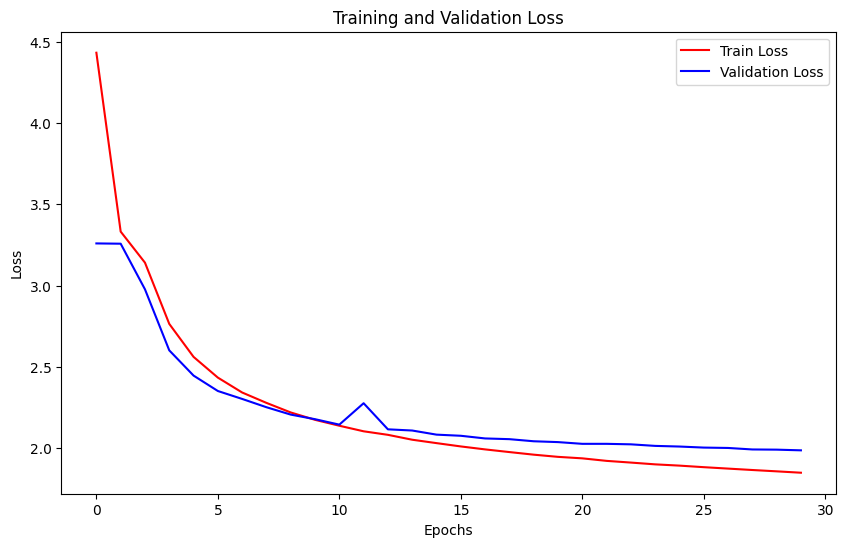

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(build_in_history['loss'], label='Train Loss', color='red')

plt.plot(build_in_history['val_loss'], label='Validation Loss', color='blue') 

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

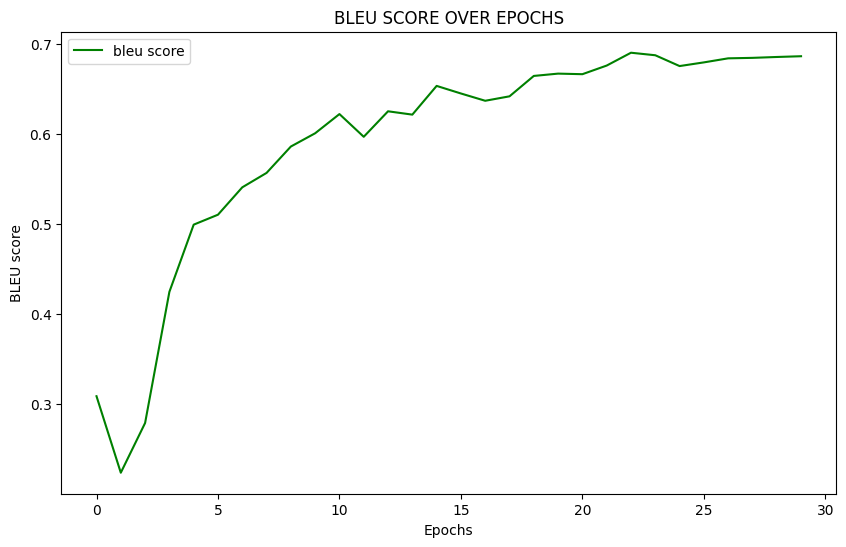

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(build_in_history['bleu'], label='bleu score', color='green')

plt.xlabel('Epochs')
plt.ylabel('BLEU score')
plt.title('BLEU SCORE OVER EPOCHS')
plt.legend()
plt.show()

In [35]:
build_in_transformer = Build_In_Transformer(src_vocab_size, tgt_vocab_size, EMB_SIZE, N_HEAD, D_FF, N_LAYER, MAX_LEN, DROPOUT)
build_in_transformer = build_in_transformer.to(device)

build_in_transformer.load_state_dict(torch.load('/kaggle/input/build-in-model-weights/saved_build_in_weights.pt'))

build_in_transformer.eval()

Build_In_Transformer(
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-5): 6 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
          )
          (linear1): Linear(in_features=512, out_features=2048, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=2048, out_features=512, bias=True)
          (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
      (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    )
    (decoder): TransformerDecoder(
      (layers): ModuleList(
        (0-5): 6 x TransformerDecoderLayer(
          (self_attn): MultiheadAt

In [36]:
def beam_search_decode(model, src, src_mask, max_len, start_symbol, end_symbol, beam_width=3, build_in=False):
    src = src.to(device)
    src_mask = src_mask.to(device)

    # 1. ENCODE
    memory = model.encoder(src, src_mask)
    memory = memory.expand(-1, beam_width, -1)
    
    src_mask = src_mask.expand(beam_width, -1, -1, -1)

    # 2. DECODE LOOP
    ys = torch.ones(1, 1).fill_(start_symbol).type(torch.long).to(device)
    
    # Beam khởi tạo
    beam_scores = torch.zeros(beam_width, device=device)
    beam_scores[1:] = float('-inf') 
    
    decoder_input = ys.expand(-1, beam_width) 
    
    completed_sequences = []

    for i in range(max_len - 1):

        sz = decoder_input.size(0)
        if build_in:
            tgt_mask = generate_square_subsequent_mask(sz).to(device)
        else:
            tgt_mask = (torch.triu(torch.ones(sz, sz, device=device)) == 1).transpose(0, 1)
        
        # Forward
        out = model.decoder(decoder_input, memory, src_mask, tgt_mask)
        
        # Lấy token cuối
        prob = model.linear(out[-1, :, :])
        log_prob = F.log_softmax(prob, dim=-1)
        
        # Cộng điểm
        next_scores = beam_scores.unsqueeze(1) + log_prob # [Beam, Vocab]
        next_scores_flat = next_scores.view(-1)
        
        # Top K
        topk_scores, topk_indices = torch.topk(next_scores_flat, beam_width)
        
        beam_indices = topk_indices.div(tgt_vocab_size, rounding_mode='floor')
        word_indices = topk_indices % tgt_vocab_size
        
        new_decoder_input = []
        new_scores = []
        
        all_eos = True 
        
        for k in range(beam_width):
            beam_idx = beam_indices[k]
            word_idx = word_indices[k]
            score = topk_scores[k]
            
            prev_seq = decoder_input[:, beam_idx]
            new_word = torch.tensor([word_idx], device=device)
            new_seq = torch.cat([prev_seq, new_word], dim=0)
            
            if word_idx == end_symbol:
                completed_sequences.append((score.item(), new_seq))
                new_scores.append(float('-inf')) 
                new_decoder_input.append(new_seq) 
            else:
                new_scores.append(score)
                new_decoder_input.append(new_seq)
                all_eos = False
        
        decoder_input = torch.stack(new_decoder_input, dim=1)
        beam_scores = torch.tensor(new_scores, device=device)
        
        if all_eos:
            break

    if len(completed_sequences) == 0:
        best_score, best_idx = torch.max(beam_scores, dim=0)
        return decoder_input[:, best_idx].unsqueeze(1)

    completed_sequences.sort(key=lambda x: x[0], reverse=True)
    best_seq = completed_sequences[0][1]
    
    return best_seq.unsqueeze(1)

def translate_beam(model, sentence, beam_width=5, build_in=False):
    sentence = sentence.lower()
    sentence = sentence.translate(str.maketrans('', '', string.punctuation))
    sentence = sentence.strip()
    sentence = re.sub(r"\s+", " ", sentence)
    model.eval()
    with torch.no_grad():
        src = text_transform[src_lang](sentence).view(-1, 1).to(device)
        num_tokens = src.shape[0]
        src_mask = (src != PAD).transpose(0, 1).unsqueeze(1).unsqueeze(2).to(device)
        
        tgt_tokens = beam_search_decode(
            model, src, src_mask, max_len=num_tokens + 10, 
            start_symbol=BOS, end_symbol=EOS, beam_width=beam_width,build_in=build_in
        ).flatten()
        
        return " ".join(vocab_transform[tgt_lang].lookup_tokens(list(tgt_tokens.cpu().numpy()))).replace("<bos>", "").replace("<eos>", "").strip()

In [37]:
transformer.load_state_dict(torch.load('/kaggle/input/model-weights/saved_weights.pt'))
#transformer.load_state_dict(torch.load('saved_weights.pt', map_location=device))
transformer.to(device)
transformer.eval()

Transformer(
  (encoder): Encoder(
    (embed): TransformerEmbedding(
      (tok_emb): TokenEmbedding(
        (embedding): Embedding(21201, 512)
      )
      (pos_emb): PositionalEncoding(
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (layers): ModuleList(
      (0-5): 6 x EncoderLayer(
        (self_attn): MultiHeadAttention(
          (w_q): Linear(in_features=512, out_features=512, bias=True)
          (w_k): Linear(in_features=512, out_features=512, bias=True)
          (w_v): Linear(in_features=512, out_features=512, bias=True)
          (w_o): Linear(in_features=512, out_features=512, bias=True)
          (softmax): Softmax(dim=-1)
        )
        (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (feed_forward): PostionWiseFeedForward(
          (fc1): Linear(in_features=512, out_features=2048, bias=True)
          (fc

In [38]:
def draw(data, x_labels, y_labels, ax):
    sns.heatmap(
        data, 
        xticklabels=x_labels, 
        yticklabels=y_labels, 
        vmin=0.0, 
        vmax=1.0, 
        cmap='viridis', 
        cbar=True,     
        cbar_kws={"shrink": 0.8},
        ax=ax, 
        square=True
    )

In [39]:
def visualize_encoder(model, src_sentence):
    model.eval()
    
    if isinstance(src_sentence, str):
        raw_tokens = get_tokenizer('basic_english')(src_sentence.lower())
        src_tokens = ['<bos>'] + raw_tokens + ['<eos>']
        
        # Chuyển sang Tensor
        src_tensor = text_transform[src_lang](src_sentence).view(-1, 1).to(device)
    else:
        print("Vui lòng nhập câu dạng chuỗi (string).")
        return

    src_mask = (src_tensor != PAD).transpose(0, 1).unsqueeze(1).unsqueeze(2).to(device)

    with torch.no_grad():
        _ = model.encoder(src_tensor, src_mask)

    # 4. Vẽ Heatmap từng Layer
    n_layers = len(model.encoder.layers)
    
    print(f"Câu Input: {src_sentence}")
    print(f"Tokens: {src_tokens}")
    
    for layer_idx in range(1, n_layers, 2):
        print(f"\n=== Encoder Layer {layer_idx + 1} ===")
        
        attn_weights = model.encoder.layers[layer_idx].self_attn.attn_weights
        
        if attn_weights is None:
            print("Không tìm thấy weights. Hãy kiểm tra lại class MultiHeadAttention.")
            return

        fig, axs = plt.subplots(1, 4, figsize=(20, 5))
        for h in range(4):
            data = attn_weights[0, h].cpu().numpy()
            
            # Cắt bớt phần padding (chỉ lấy đúng độ dài câu)
            seq_len = len(src_tokens)
            data = data[:seq_len, :seq_len]
            
            draw(data, src_tokens, src_tokens, axs[h])
            axs[h].set_title(f'Head {h+1}')
        
        plt.show()

In [40]:
def visualize_decoder(model, src_sent, build_in=False):
    if build_in:
        print("Không hỗ trợ")
        return

    model.eval()
    with torch.no_grad():
        trans_sent = translate_sentence(model, src_sent, build_in=False)

    print(f"Original: {src_sent}")
    print(f"Translated: {trans_sent}")

    if isinstance(src_sent, str):
        src_tokens = ['<bos>'] + get_tokenizer('basic_english')(src_sent.lower()) + ['<eos>']
    
    if isinstance(trans_sent, str):
        trg_tokens = ['<bos>'] + vi_tokenize(trans_sent) + ['<eos>']
    else:
        # Dự phòng nếu trans_sent là list
        trg_tokens = ['<bos>'] + trans_sent + ['<eos>']

    n_layers = len(model.decoder.layers)
    
    for layer_idx in range(1, n_layers, 2):
        
        print(f"\n=== Decoder Self-Attention (Layer {layer_idx + 1}) ===")
        fig, axs = plt.subplots(1, 4, figsize=(20, 5))
        
        attn_obj = model.decoder.layers[layer_idx].attn1
        attn_data = attn_obj.attn_weights 
        
        if attn_data is not None:
            for h in range(min(4, attn_data.shape[1])):
                len_trg = len(trg_tokens)
                limit = min(len_trg, attn_data.shape[2])
                
                data = attn_data[0, h, :limit, :limit].cpu().numpy()
                
                draw(data, trg_tokens[:limit], trg_tokens[:limit] if h==0 else [], ax=axs[h])
                axs[h].set_title(f'Head {h+1}')
            plt.show()

        print(f"=== Decoder Src-Attention (Layer {layer_idx + 1}) ===")
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        
        attn_obj = model.decoder.layers[layer_idx].attn2
        attn_data = attn_obj.attn_weights
        
        if attn_data is not None:
            for h in range(min(4, attn_data.shape[1])):
                len_src = len(src_tokens)
                len_trg = len(trg_tokens)
                
                limit_y = min(len_trg, attn_data.shape[2])
                limit_x = min(len_src, attn_data.shape[3])

                data = attn_data[0, h, :limit_y, :limit_x].cpu().numpy()
                
                draw(data, src_tokens[:limit_x], trg_tokens[:limit_y] if h==0 else [], ax=axs[h])
                axs[h].set_title(f'Head {h+1}')
            plt.show()

Câu Input: he is a really sensitive man
Tokens: ['<bos>', 'he', 'is', 'a', 'really', 'sensitive', 'man', '<eos>']

=== Encoder Layer 2 ===


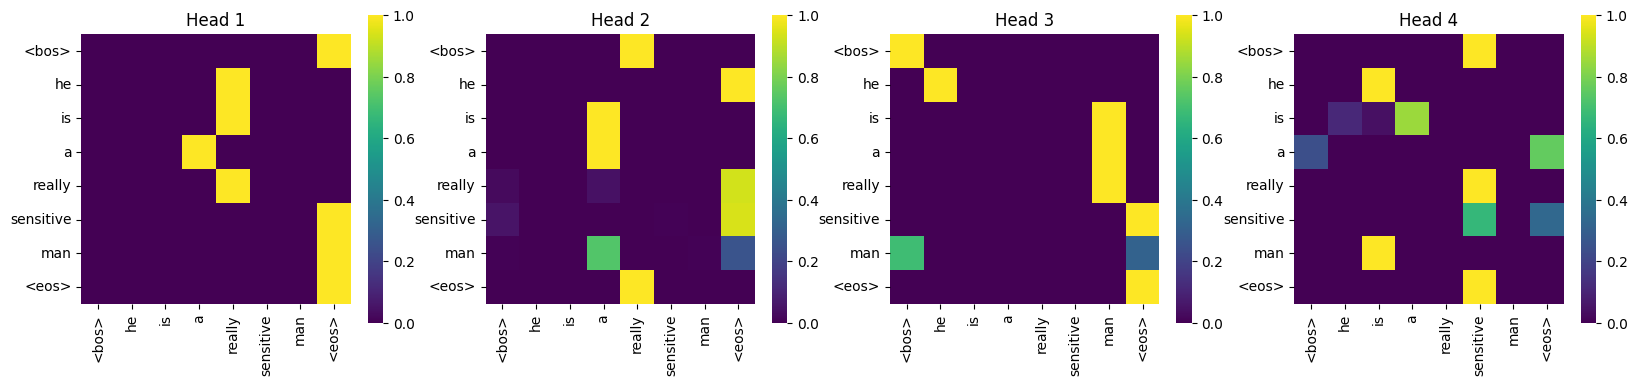


=== Encoder Layer 4 ===


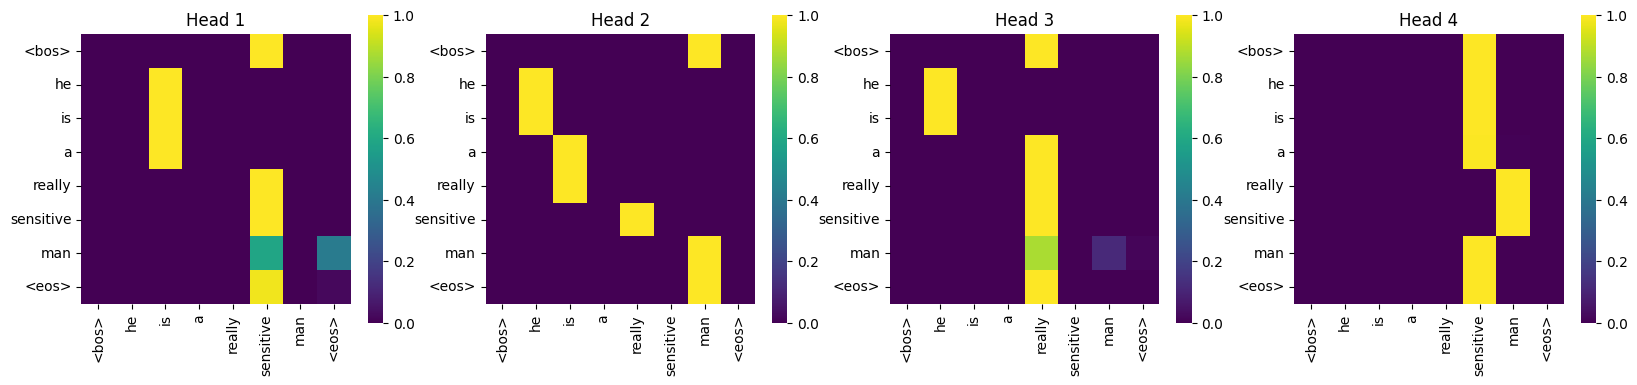


=== Encoder Layer 6 ===


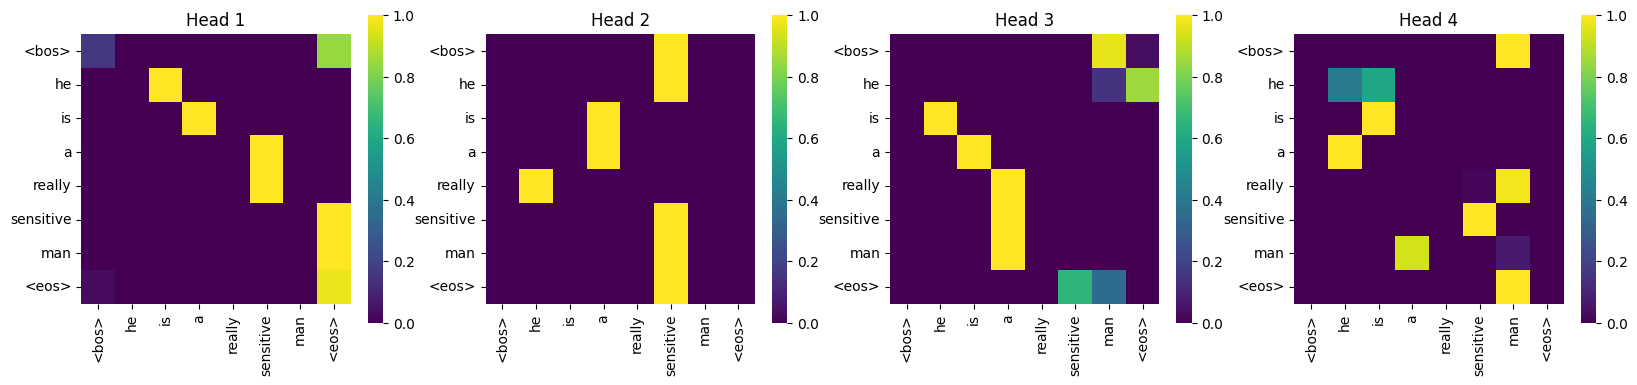

In [41]:
src_ex = "he is a really sensitive man"
visualize_encoder(transformer, src_ex)

Original: he is a really sensitive man
Translated: anh ấy là một người đàn ông thực sự nhạy cảm

=== Decoder Self-Attention (Layer 2) ===


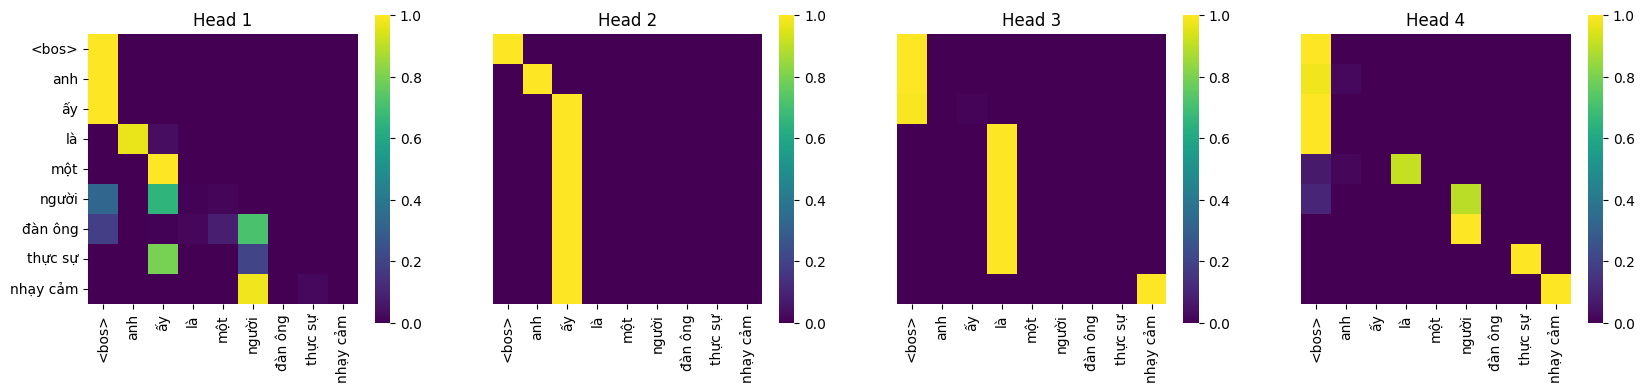

=== Decoder Src-Attention (Layer 2) ===


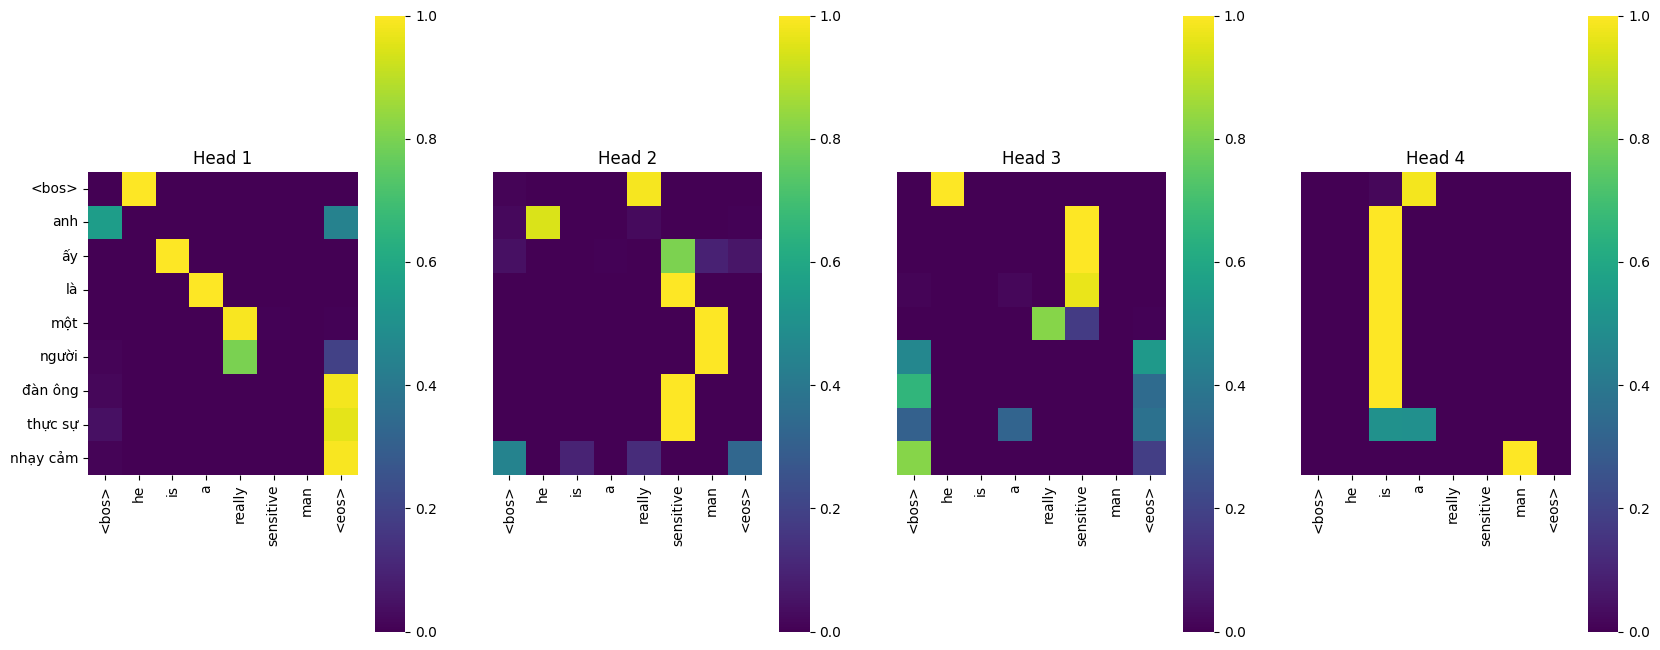


=== Decoder Self-Attention (Layer 4) ===


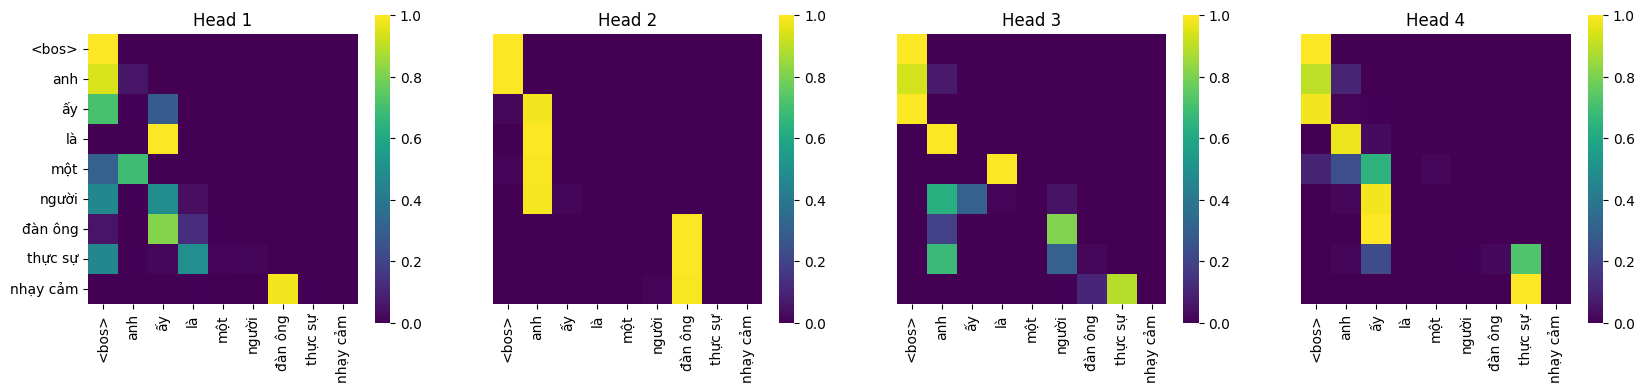

=== Decoder Src-Attention (Layer 4) ===


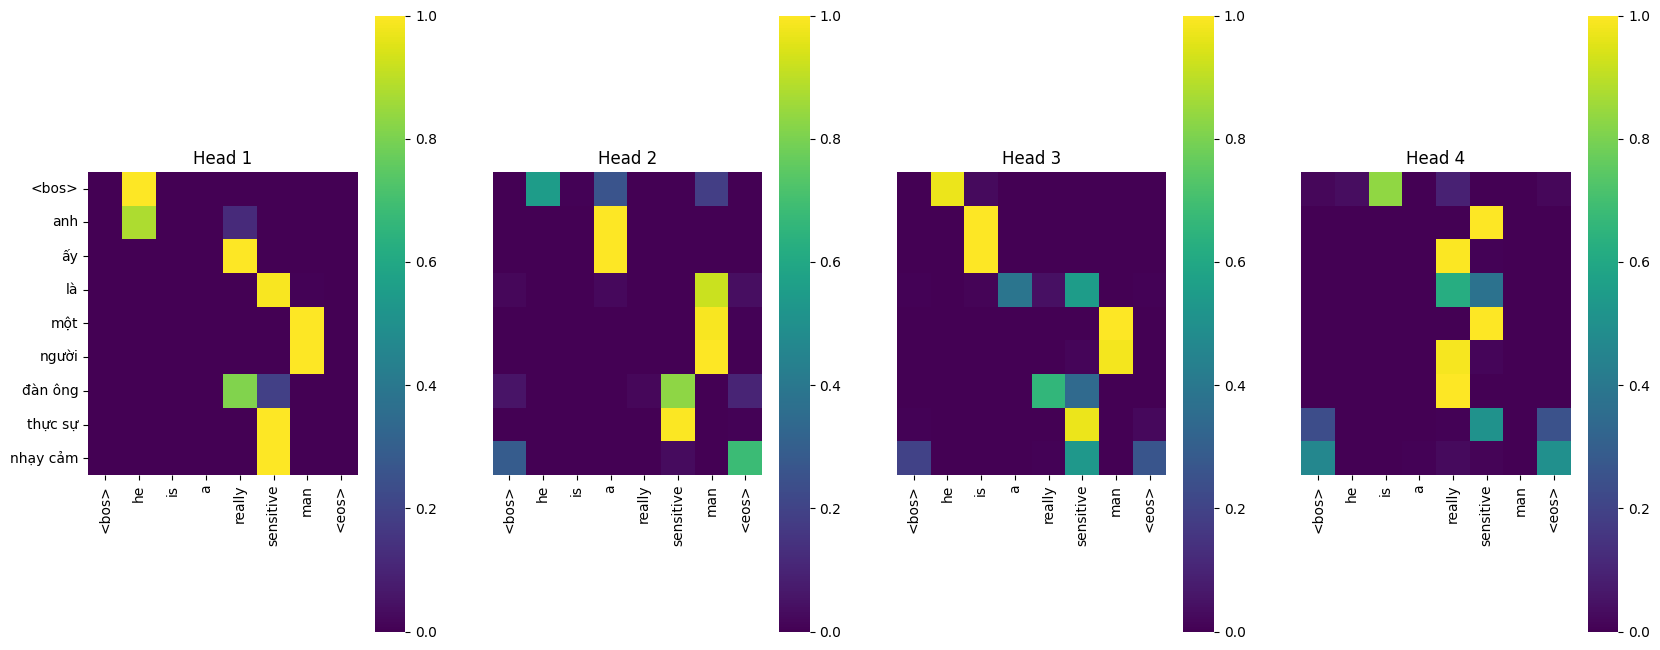


=== Decoder Self-Attention (Layer 6) ===


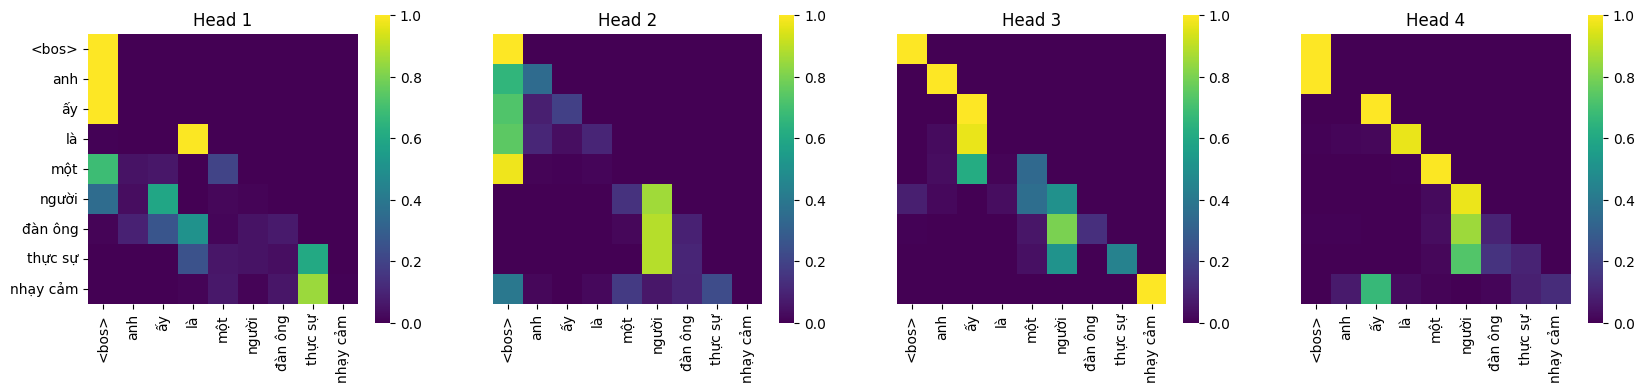

=== Decoder Src-Attention (Layer 6) ===


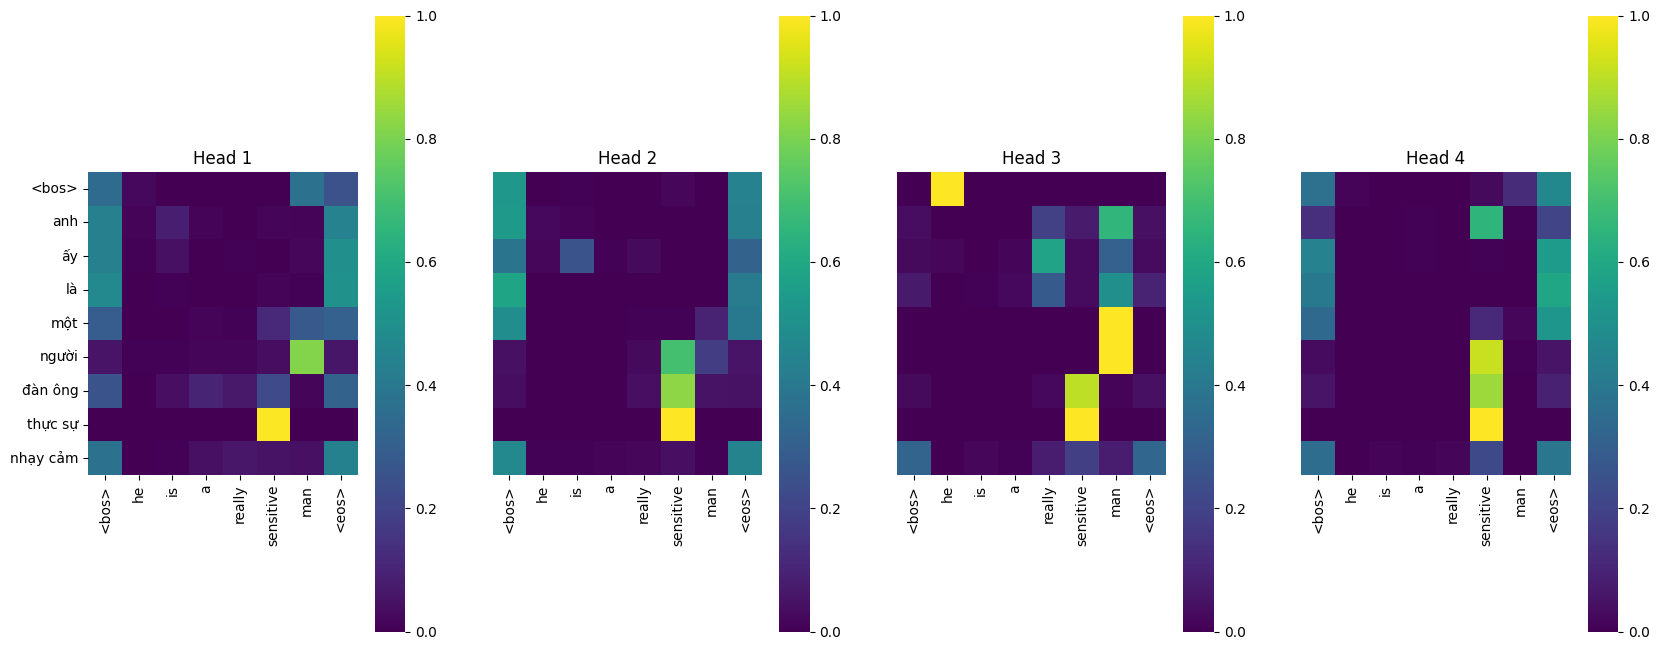

In [42]:
visualize_decoder(transformer,src_ex,build_in=False)

In [43]:
from nltk.translate.bleu_score import sentence_bleu
test_data = val_ds[:10] 

print(" KIỂM TRA BLEU & DỊCH THỬ TRÊN 10 CÂU ĐẦU TIÊN")

for i, item in enumerate(test_data):
    src = item[0]
    tgt = item[1] 
    
    pred = translate_sentence(transformer, src)
    
    tgt_tokens = [vi_tokenize(tgt)]
    pred_tokens = vi_tokenize(pred)
    bleu_score = sentence_bleu(tgt_tokens, pred_tokens, smoothing_function=SmoothingFunction().method2)

    print(f"Câu {i+1}:")
    print(f"  Input:   {src}")
    print(f"  Target:  {tgt}")
    print(f"  Predict: {pred}")
    print(f"  Bleu: {bleu_score*100:.2f}")
    print("-" * 50)

 KIỂM TRA BLEU & DỊCH THỬ TRÊN 10 CÂU ĐẦU TIÊN
Câu 1:
  Input:   i thought you needed the sleep
  Target:  tôi nghĩ bạn cần ngủ
  Predict: tôi nghĩ bạn cần ngủ
  Bleu: 100.00
--------------------------------------------------
Câu 2:
  Input:   you will survive
  Target:  bạn sẽ sống sót
  Predict: bạn sẽ sống sót
  Bleu: 84.09
--------------------------------------------------
Câu 3:
  Input:   he is a doctor and also a novelist
  Target:  ông là một bác sĩ và cũng là một tiểu thuyết gia
  Predict: ông là bác sĩ và cũng là một tiểu thuyết gia
  Bleu: 70.90
--------------------------------------------------
Câu 4:
  Input:   what you were taught is wrong
  Target:  những gì bạn đã được dạy là sai
  Predict: những gì bạn đã được dạy là sai
  Bleu: 100.00
--------------------------------------------------
Câu 5:
  Input:   i shouldve known tom would be here too
  Target:  tôi cũng nên biết tom cũng sẽ ở đây
  Predict: tôi nên biết tom cũng sẽ ở đây
  Bleu: 74.77
--------------------------